In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

# Mục mới

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/datamining/heart.csv'
df = pd.read_csv(file_path)

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


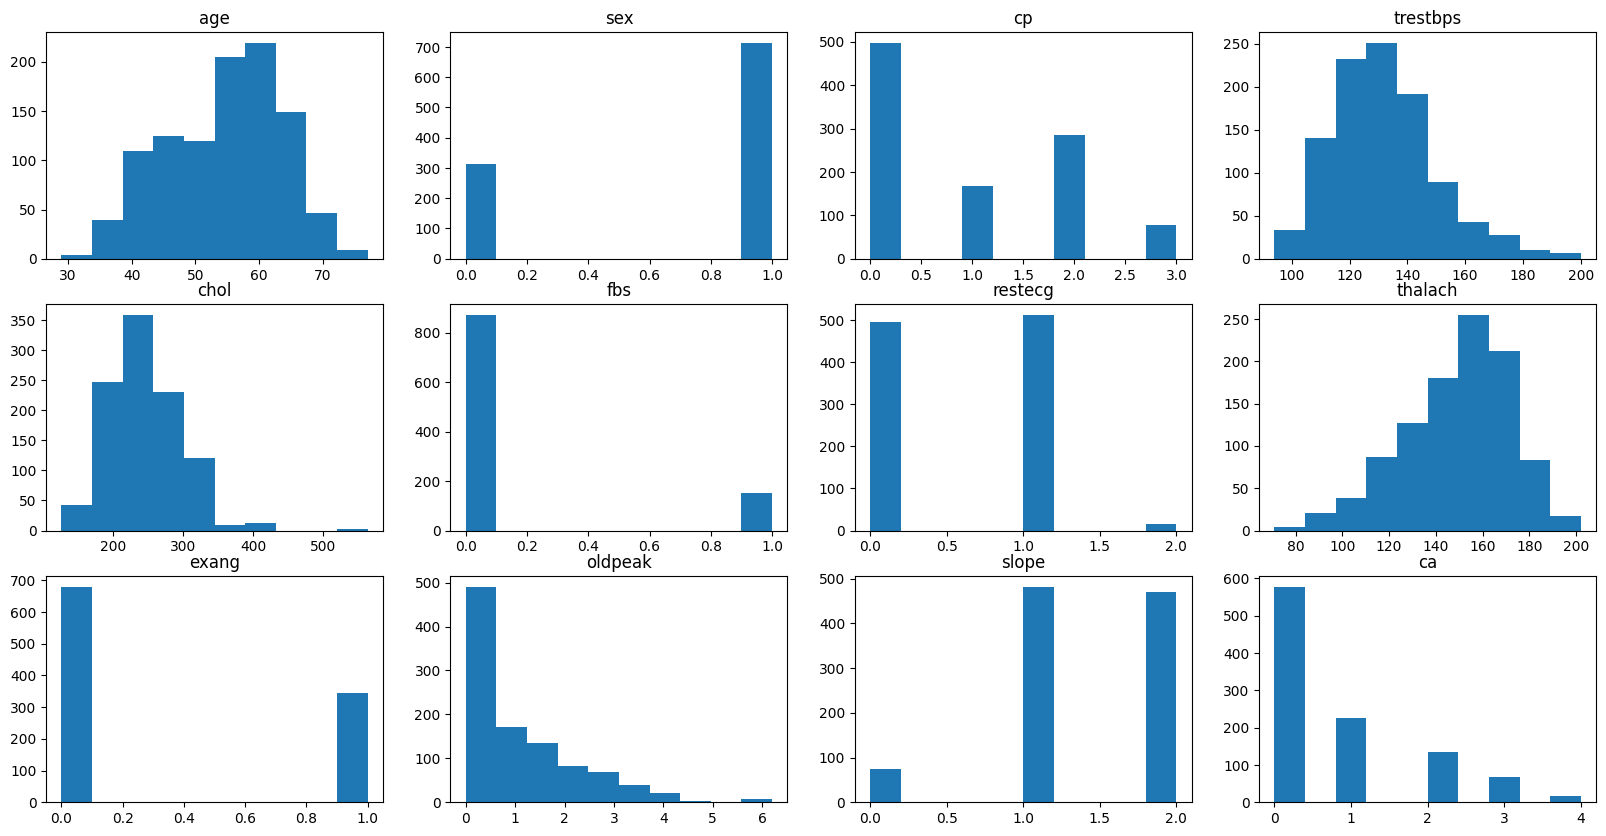

In [ ]:
figure, axis = plt.subplots(3, 4,figsize=(20, 10))
axis[0,0].hist(df['age'])
axis[0,0].set_title('age')
axis[0,1].hist(df['sex'])
axis[0,1].set_title('sex')
axis[0,2].hist(df['cp'])
axis[0,2].set_title('cp')
axis[0,3].hist(df['trestbps'])
axis[0,3].set_title('trestbps')
axis[1,0].hist(df['chol'])
axis[1,0].set_title('chol')
axis[1,1].hist(df['fbs'])
axis[1,1].set_title('fbs')
axis[1,2].hist(df['restecg'])
axis[1,2].set_title('restecg')
axis[1,3].hist(df['thalach'])
axis[1,3].set_title('thalach')
axis[2,0].hist(df['exang'])
axis[2,0].set_title('exang')
axis[2,1].hist(df['oldpeak'])
axis[2,1].set_title('oldpeak')
axis[2,2].hist(df['slope'])
axis[2,2].set_title('slope')
axis[2,3].hist(df['ca'])
axis[2,3].set_title('ca')
plt.show()

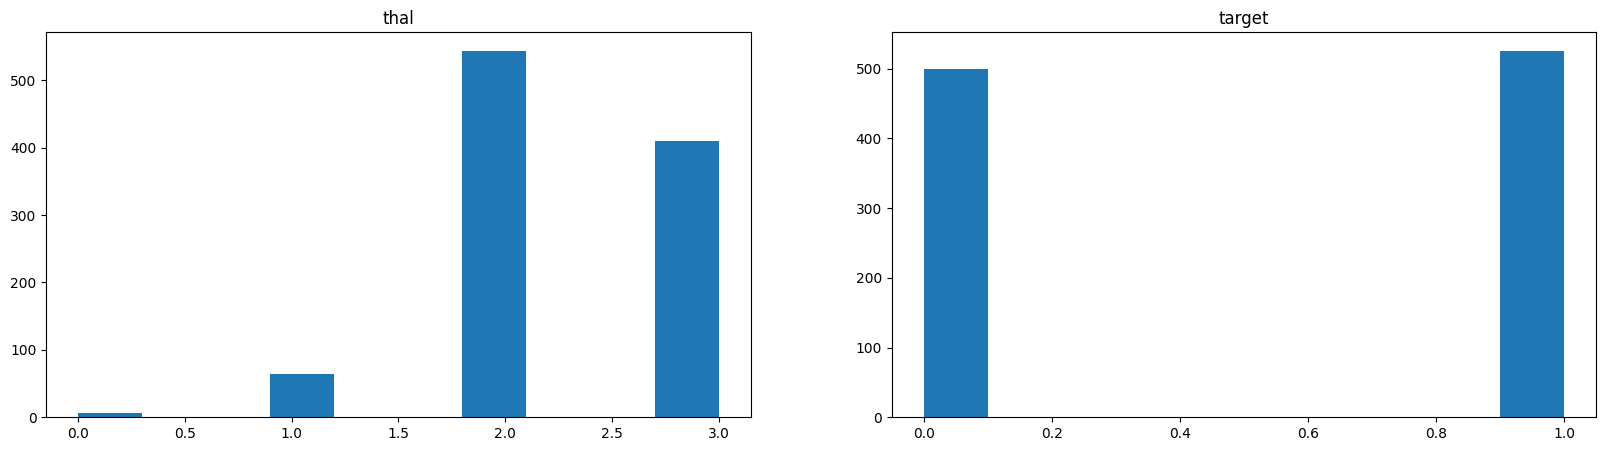

In [ ]:
fixgure, axis = plt.subplots(1, 2, figsize=(20, 5))
axis[0].hist(df['thal'])
axis[0].set_title('thal')
axis[1].hist(df['target'])
axis[1].set_title('target')
plt.show()

tiến hành xử lý dữ liệu để triển khai mô hình


In [ ]:
x = df.drop('target', axis=1)
y = df['target']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((820, 13), (205, 13), (820,), (205,))

Độ chính xác của Decision Tree: 98.54%
Confusion Matrix:
 [[102   0]
 [  3 100]]
Độ nhạy (Recall): 0.97
Độ đặc hiệu (Specificity): 1.00
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



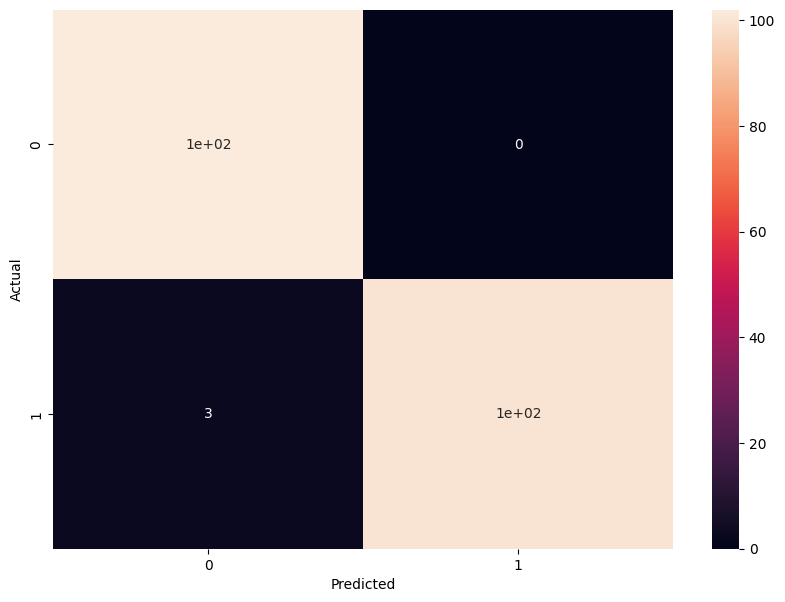

In [ ]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(x_train, y_train)

y_pred_dt = model_dt.predict(x_test)
cm = confusion_matrix(y_test, y_pred_dt)
accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Độ chính xác của Decision Tree: {accuracy*100:.2f}%")
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"Độ nhạy (Recall): {recall:.2f}")
print(f"Độ đặc hiệu (Specificity): {specificity:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

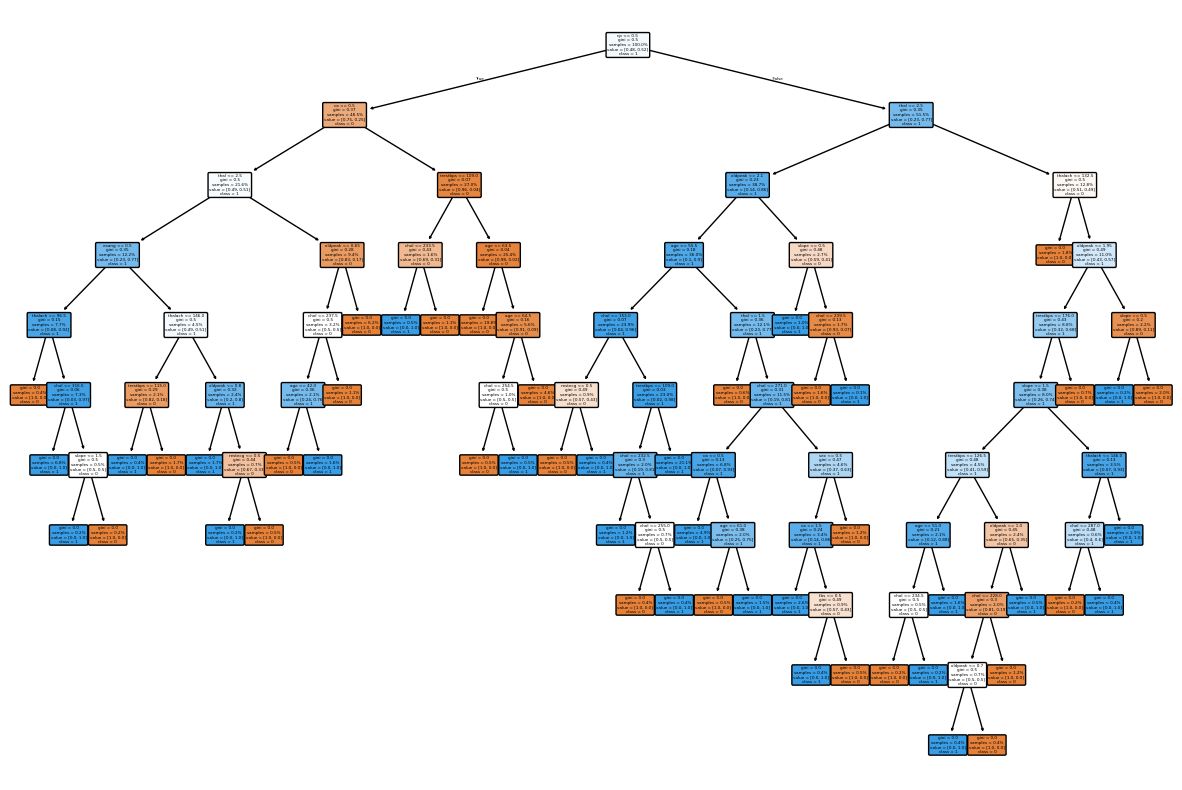

In [ ]:
#in cay quyết định
plt.figure(figsize=(15,10))
plot_tree(model_dt,
          filled=True,
          feature_names=x.columns,
          class_names=['0', '1'],
          fontsize=3,  # Tăng kích thước font chữ
          rounded=True, # Làm tròn các góc của node
          proportion=True, # Điều chỉnh kích thước node theo tỷ lệ mẫu
          precision=2)  # Giới hạn số chữ số thập phân cho các giá trị
plt.show()

#so sánh so với các mô hình khác


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
# Logistic Regression
logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(x_train, y_train)
pred_logit = logit_model.predict(x_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
pred_rf = rf_model.predict(x_test)

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)
pred_knn = knn_model.predict(x_test)


=== Logistic Regression ===
Confusion Matrix:
 [[73 29]
 [13 90]]
Độ chính xác: 0.7951219512195122
Độ nhạy (Recall): 0.87
Độ đặc hiệu (Specificity): 0.72
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205


=== Random Forest ===
Confusion Matrix:
 [[102   0]
 [  3 100]]
Độ chính xác: 0.9853658536585366
Độ nhạy (Recall): 0.97
Độ đặc hiệu (Specificity): 1.00
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99  

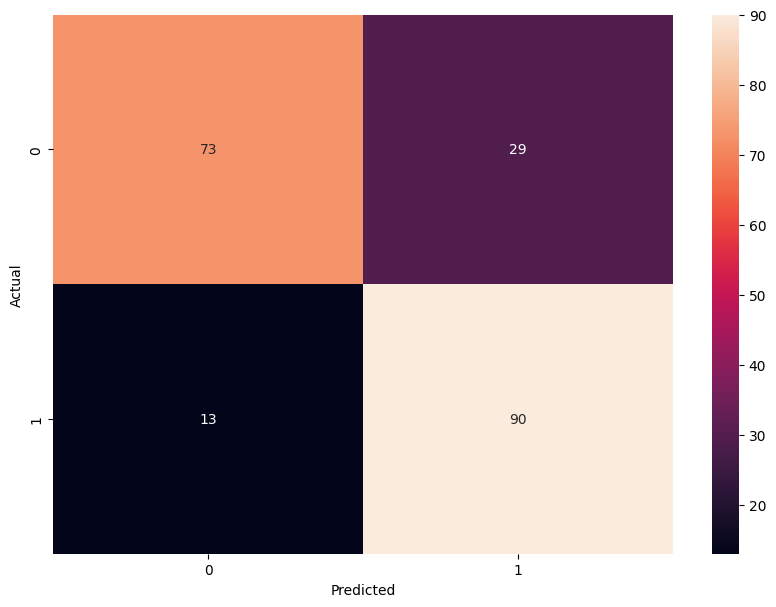

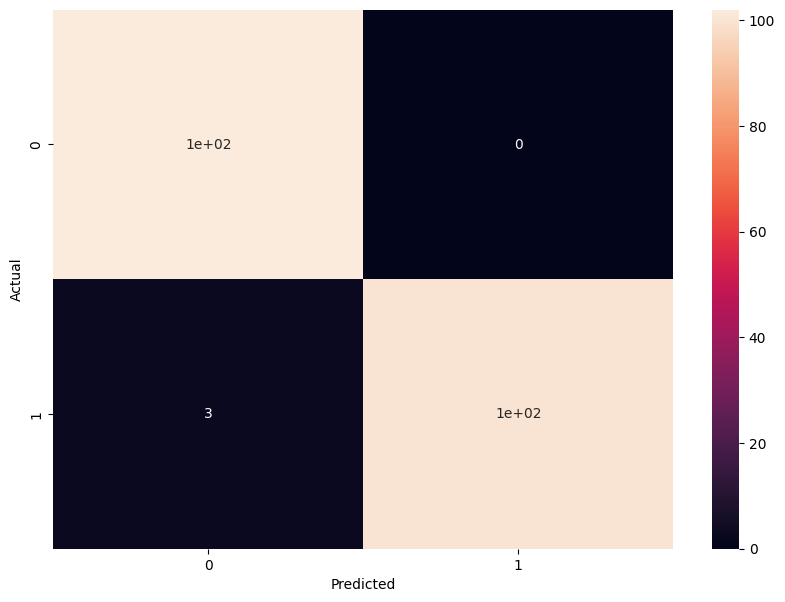

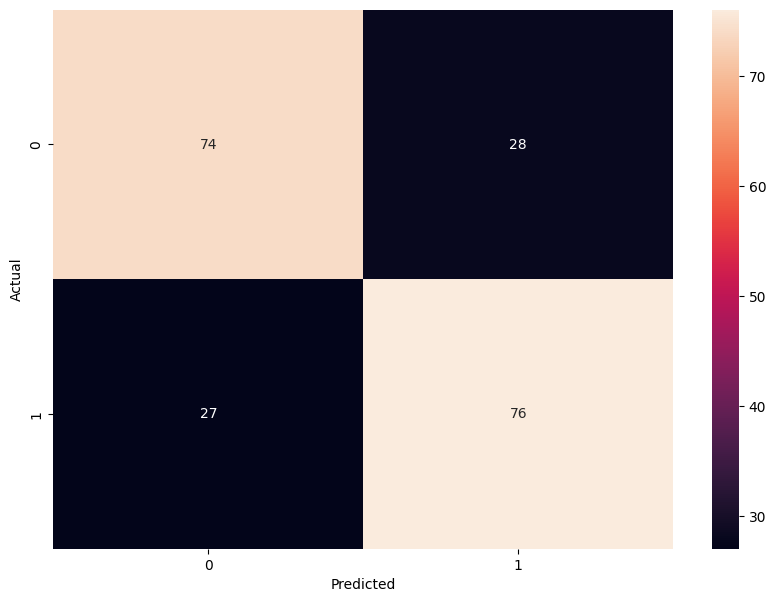

In [ ]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    plt.figure(figsize=(10,7))
    sns.heatmap(confusion_matrix(y_true, y_pred),annot=True)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    print("Độ chính xác:", accuracy_score(y_true, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Độ nhạy (Recall): {recall:.2f}")
    print(f"Độ đặc hiệu (Specificity): {specificity:.2f}")
    print("Classification Report:\n", classification_report(y_true, y_pred))
evaluate_model("Logistic Regression", y_test, pred_logit)
evaluate_model("Random Forest", y_test, pred_rf)
evaluate_model("K-Nearest Neighbors", y_test, pred_knn)

In [ ]:
sample = {
    'age': [65],
    'sex': [1],
    'cp': [3],
    'trestbps': [160],
    'chol': [290],
    'fbs': [1],
    'restecg': [2],
    'thalach': [105],
    'exang': [1],
    'oldpeak': [3.5],
    'slope': [0],
    'ca': [2],
    'thal': [3]
}
sample_df = pd.DataFrame(sample)

In [ ]:
prediction = model_dt.predict(sample_df)

In [ ]:
if prediction[0] == 1:
    print("Có khả năng bị bệnh tim.")
else:
    print("Không có khả năng bị bệnh tim.")

Không có khả năng bị bệnh tim.
